## 1. Environment Setup

In [3]:
# Install / upgrade dependencies
!pip install -q gensim spacy
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import re
import glob
import pandas as pd
from time import time
from collections import defaultdict
import multiprocessing

import spacy
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser

import logging
logging.basicConfig(
    format="%(levelname)s - %(asctime)s: %(message)s",
    datefmt='%H:%M:%S',
    level=logging.INFO
)

print("All imports OK")

All imports OK


## 2. Loading COHA Files

COHA `.txt` files have a specific markup format. We load every `.txt` file in the target folder and split on document boundaries.

In [50]:
COHA_GLOB = "/content/*.txt"
# If running locally with the uploaded files:
# COHA_GLOB = "/mnt/user-data/uploads/*.txt"
# ──────────────────────────────────────────────────────────────────────────────

raw_docs = []
file_paths = sorted(glob.glob(COHA_GLOB))


for fp in file_paths:
    with open(fp, encoding='utf-8', errors='replace') as f:
        content = f.read()
    # Split on document-boundary markers (@@XXXX)
    parts = re.split(r'@@\d+', content)
    for part in parts:
        stripped = part.strip()
        if stripped:
            raw_docs.append(stripped)

print(f"Loaded {len(file_paths)} file(s) → {len(raw_docs)} document segment(s)")
print("\nFirst 300 chars of first segment:")
print(raw_docs[0][:300])

Loaded 20 file(s) → 20 document segment(s)

First 300 chars of first segment:
The author is indebted to one of the novels of Le Brun , for the ground-work of this little comedy . DRAMATIS PERSON . Philadelphia Count Almeyda Mr. Robertson Count Arandez Warren Carlos Wood Pacomo Jefferson Gusman Abercrombie Pedrillo Durang Herald Jackson Eugenia Mrs. Entwistle Beatrice Francis 


## 3. Cleaning & Preprocessing

We apply a multi-step cleaning pipeline tailored to COHA dramatic fiction:

1. Strip COHA redaction markers (`@ @ @ @ @ @ @ @ @ @`)
2. Remove stage directions in parentheses — `( exits hastily )`
3. Remove character name headers — COHA uses `Name . Name speech…` patterns
4. Remove section headers — `Main text`, `ACT`, `SCENE`, `DRAMATIS PERSON`
5. Keep only alphabetic tokens and lowercase
6. Lemmatize & remove stopwords via spaCy

In [51]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def coha_preprocess(text: str) -> str:
    """Strip COHA markup and dramatic-text noise from a raw document string."""
    # 1. Remove redaction markers (space-separated @ symbols)
    text = re.sub(r'(?:@\s*)+', ' ', text)

    # 2. Remove stage directions in parentheses (including nested)
    text = re.sub(r'\([^)]*\)', ' ', text)

    # 3. Remove structural headers typical of COHA dramatic texts
    headers = [
        r'Main text', r'DRAMATIS PERSON\.?', r'ACT\s+[IVXLC]+\.?',
        r'SCENE\s+[IVXLC]+', r'SCENE\s+\w+', r'CHORUS',
        r'END\s+OF\s+ACT', r'STAGE DIRECTIONS', r'EXITS? AND ENTRANCES?',
        r'RELATIVE POSITIONS?',
    ]
    for h in headers:
        text = re.sub(h, ' ', text, flags=re.IGNORECASE)

    # 4. Remove character-name prefixes: "Carlos . Carlos" or "Eug . Eugenia"
    #    Pattern: short abbreviation, dot, full name (all followed by the speech)
    text = re.sub(r'\b[A-Z][a-z]{0,6}\s*\.\s*[A-Z][a-zA-Z]+\s+', ' ', text)

    # 5. Remove ALL-CAPS single words (stage direction labels like "Aside", "R.", "L.")
    text = re.sub(r'\b[A-Z]{2,}\b\.?', ' ', text)

    # 6. Collapse whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


#spaCy cleaning (lemmatize, remove stopwords, keep only alpha) ──────────────

def spacy_clean(doc) -> str | None:
    """Lemmatize and remove stopwords/punctuation. Returns None for very short docs."""
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and token.is_alpha and len(token.text) > 1
    ]
    if len(tokens) > 2:
        return ' '.join(tokens)
    return None


print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


In [52]:
#COHA-specific cleaning
prepped_texts = [coha_preprocess(doc) for doc in raw_docs]

# Preview one result
print("After COHA pre-cleaning (first 300 chars):")
print(prepped_texts[0][:30])

After COHA pre-cleaning (first 300 chars):
The author is indebted to one 


In [53]:
# ── Step 2: spaCy lemmatization ─────────────────────────────────────────────────
# We also apply a brief regex pass to remove remaining non-alpha chars
brief_clean = (
    re.sub(r"[^A-Za-z']+", ' ', text).lower()
    for text in prepped_texts
)

t = time()
cleaned = [
    spacy_clean(doc)
    for doc in nlp.pipe(brief_clean, batch_size=200)
]
print(f"spaCy cleaning took {round((time() - t) / 60, 2)} min")

# Collect into a DataFrame and drop nulls / duplicates
df_clean = pd.DataFrame({'clean': cleaned}).dropna().drop_duplicates().reset_index(drop=True)
print(f"Clean segments: {len(df_clean)}")
df_clean.head()

spaCy cleaning took 1.17 min
Clean segments: 20


,clean
0,author indebted novel le brun ground work litt...
1,alexius emperour bouillon duke lorraine bohemo...
2,oh love world make fatal love ah cypress branc...
3,feeble sincere testimonial respect entertain o...
4,motto virginia copy right secure accord law le...


In [54]:
# Quick sanity check — most common tokens
from collections import Counter
all_words = ' '.join(df_clean['clean']).split()
print("Total tokens aftezr cleaning:", len(all_words))
print("\nTop 20 most common tokens:")
Counter(all_words).most_common(20)

Total tokens aftezr cleaning: 262976

Top 20 most common tokens:


[('say', 2560),
 ('know', 1737),
 ('come', 1664),
 ('like', 1592),
 ('look', 1558),
 ('man', 1545),
 ('think', 1421),
 ('go', 1228),
 ('time', 1178),
 ('good', 1049),
 ('hand', 1021),
 ('little', 985),
 ('tell', 981),
 ('day', 967),
 ('eye', 862),
 ('long', 841),
 ('way', 835),
 ('thing', 832),
 ('love', 831),
 ('see', 816)]

## 4. Bigrams

We use Gensim's `Phrases` to detect commonly co-occurring word pairs.
In a historical drama corpus this captures expressions like `count_almeyda`, `evil_eye`, `holy_land`, etc.

In [55]:
# Convert each cleaned segment to a list of words
sent = [row.split() for row in df_clean['clean']]
print(f"{len(sent)} sentence lists")

# ── Bigram detection ───────────────────────────────────────────────────────────
# min_count is lower than the Simpsons tutorial because COHA sample is smaller.
# Increase to 10–30 when using the full COHA corpus.
phrases = Phrases(sent, min_count=3, threshold=5, progress_per=500)
bigram  = Phraser(phrases)
sentences = list(bigram[sent])

# Show detected bigrams
bigrams_found = [
    token for seg in sentences for token in seg if '_' in token
]
print(f"\nExample bigrams detected ({len(set(bigrams_found))} unique):")
print(sorted(set(bigrams_found))[:30])

20 sentence lists

Example bigrams detected (1682 unique):
['accept_invitation', 'adopt_son', 'affair_heart', 'afford_opportunity', 'afraid_die', 'afternoon_evening', 'afternoon_reception', 'afternoon_sit', 'afterward_learn', 'ah_dream', 'ah_ha', 'ah_sir', 'ah_yes', 'aide_aide', 'aide_de', 'air_ship', 'almeyda_arandez', 'almeyda_count', 'amber_mist', 'american_indians', 'anderson_cloutier', 'animal_spirit', 'answer_claudius', 'answer_question', 'appear_doorway', 'apple_pear', 'apple_tree', 'april_st', 'april_th', 'arandez_act']


In [56]:
# Word frequency distribution
word_freq = defaultdict(int)
for seg in sentences:
    for w in seg:
        word_freq[w] += 1

print(f"Vocabulary size (before min_count filter): {len(word_freq)}")
print("\nTop 15 tokens:")
sorted(word_freq, key=word_freq.get, reverse=True)[:15]

Vocabulary size (before min_count filter): 19917

Top 15 tokens:


['say',
 'know',
 'come',
 'like',
 'think',
 'look',
 'man',
 'go',
 'time',
 'day',
 'tell',
 'little',
 'see',
 'thing',
 'way']

## 5. Training the Model

### Parameter notes for COHA

| Parameter | Simpsons value | COHA (sample) value | Rationale |
|---|---|---|---|
| `min_count` | 20 | **5** | Smaller corpus → keep rarer words |
| `window` | 2 | **5** | Longer sentences in formal prose |
| `vector_size` | 300 | **100** | Proportional to corpus size |
| `sample` | 6e-5 | **1e-4** | Less aggressive downsampling |
| `epochs` | 30 | **30** | Same |

> When you scale to the full COHA (~400 million words) you can safely raise `min_count` to 20, `vector_size` to 300, and lower `sample` to 6e-5 as in the original tutorial.

In [57]:
cores = multiprocessing.cpu_count()
print(f"CPU cores available: {cores}")

w2v_model = Word2Vec(
    min_count   = 5,
    window      = 5,
    vector_size = 100,
    sample      = 1e-4,
    alpha       = 0.03,
    min_alpha   = 0.0007,
    negative    = 20,
    workers     = max(1, cores - 1)
)

CPU cores available: 2


In [58]:
#build the vocabulary
t = time()
w2v_model.build_vocab(sentences, progress_per=1000)
print(f"Vocabulary built in {round((time() - t) / 60, 2)} min")
print(f"Vocabulary size: {len(w2v_model.wv)}")

Vocabulary built in 0.0 min
Vocabulary size: 7271


In [59]:
#train the model
t = time()
w2v_model.train(
    sentences,
    total_examples = w2v_model.corpus_count,
    epochs         = 30,
    report_delay   = 1
)
print(f"Model trained in {round((time() - t) / 60, 2)} min")

Model trained in 0.4 min


In [60]:
#lock the vectors (memory-efficient after training)
w2v_model.wv.vectors_lockf = 0.0   # Gensim 4.x replacement for init_sims(replace=True)

#save for later use
w2v_model.save("coha_word2vec.model")
print("Model saved as coha_word2vec.model")

Model saved as coha_word2vec.model


## 6. Exploring the Model

substitute Simpsons character queries with vocabulary appropriate to early 19th-century dramatic prose.

### Most-similar words

In [61]:
#helper to print results cleanly
def show_similar(word, topn=10):
    try:
        results = w2v_model.wv.most_similar(positive=[word], topn=topn)
        print(f"\nMost similar to '{word}':")
        for w, score in results:
            print(f"  {w:<20} {score:.4f}")
    except KeyError:
        print(f"'{word}' not in vocabulary — try another word.")

In [62]:
show_similar("love")


Most similar to 'love':
  sacred               0.9336
  heart                0.9162
  die                  0.9158
  weak                 0.9126
  pain                 0.9104
  bitter               0.9067
  love_love            0.8871
  grieve               0.8832
  tender               0.8829
  cherish              0.8801


In [63]:
show_similar("fate")


Most similar to 'fate':
  cherish              0.9158
  lover                0.9129
  innocent             0.9102
  living               0.9066
  faithful             0.9060
  sin                  0.9053
  ardent               0.9007
  rapture              0.8998
  suffering            0.8992
  freely               0.8991


In [64]:
show_similar("honour")


Most similar to 'honour':
  commit               0.9282
  forbid               0.9224
  confess              0.9167
  demand               0.9149
  service              0.9146
  duty                 0.9145
  league               0.9133
  acknowledge          0.9127
  soldier              0.9068
  presume              0.9058


In [65]:
# Try any word from the vocabulary
show_similar("heart")
show_similar("villain")


Most similar to 'heart':
  grieve               0.9659
  die                  0.9621
  weep                 0.9587
  pain                 0.9582
  forever              0.9513
  distress             0.9465
  despair              0.9411
  heaven               0.9363
  tender               0.9337
  grief                0.9319

Most similar to 'villain':
  vow                  0.9303
  coward               0.9292
  mistress             0.9198
  swear                0.9156
  murder               0.9141
  spain                0.9130
  devil                0.9128
  defy                 0.9071
  revenge              0.9052
  count_arandez        0.9032


### Similarity scores between pairs

In [66]:
#liste de paires de mots pour lesquelles on veut mesurer la similarité
#chaque tuple contient (mot1, mot2)
pairs = [
    ("love",    "passion"),
    ("love",    "hatred"),
    ("father",  "daughter"),
    ("sword",   "honour"),
    ("villain", "hero"),
]

#affichage de l’en-tête du tableau
# {:<30} = aligné à gauche sur 30 caractères
# {:>10} = aligné à droite sur 10 caractères
print(f"{'Pair':<30} {'Similarity':>10}")
print("-" * 42)

#boucle sur chaque paire de mots
for w1, w2 in pairs:
    try:
        #calcul de la similarité cosinus entre les deux mots
        #w2v_model.wv.similarity() renvoie une valeur entre -1 et 1
        sim = w2v_model.wv.similarity(w1, w2)

        #affichage formaté : mot1 / mot2 + score arrondi à 4 décimales
        print(f"{w1} / {w2:<25} {sim:>10.4f}")

    except KeyError as e:
        # Si un mot n’est pas dans le vocabulaire du modèle Word2Vec
        print(f"{w1} / {w2:<25} {str(e)} not in vocab")


Pair                           Similarity
------------------------------------------
love / passion                       0.6194
love / hatred                        0.5371
father / daughter                      0.8294
sword / honour                        0.1470
villain / hero                          0.0280


### Diff distances de similarité

In [67]:
#Check which candidate words actually exist in the COHA vocabulary,
#then compare pairwise cosine similarities via Word2Vec.

# Sanity check: is a specific compound/name in the vocabulary?
"love_passion" in w2v_model.wv.key_to_index

False

In [68]:
# Filter a candidate list to only keep in-vocabulary words
candidate_words = ["love", "honour", "sword", "death", "villain", "hero",
                   "father", "daughter", "passion", "fate"]
words_in_vocab = [w for w in candidate_words if w in w2v_model.wv.key_to_index]
print("In-vocabulary candidates:", words_in_vocab)

In-vocabulary candidates: ['love', 'honour', 'sword', 'death', 'villain', 'hero', 'father', 'daughter', 'passion', 'fate']


In [69]:
# Pairwise similarities — anchor word: "love"
w2v_model.wv.similarity("love", "passion")
w2v_model.wv.similarity("love", "honour")
w2v_model.wv.similarity("love", "sword")
w2v_model.wv.similarity("love", "death")

np.float32(0.85378456)

### Build a co-occurrence matrix

In [70]:
#A Distributional Semantic Model (DSM) counts how often two words appear
#in the same context window — no neural training required.
#We then compare its cosine similarity scores to the Word2Vec scores above.

from collections import defaultdict
import numpy as np
import pandas as pd

Build co-occurrence counts

In [71]:
window_size = 2
cooc = defaultdict(lambda: defaultdict(int))

for sent in sentences:
    for i, word in enumerate(sent):
        start = max(0, i - window_size)
        end   = min(len(sent), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                context_word = sent[j]
                cooc[word][context_word] += 1


Convert to a DataFrame (words × context-words)

In [72]:
cooc_df = pd.DataFrame.from_dict(cooc, orient="index").fillna(0)
print(f"Co-occurrence matrix shape: {cooc_df.shape}")

Co-occurrence matrix shape: (19917, 19917)


Compute cosine similarity from the co-occurrence matrix

In [73]:
from sklearn.metrics.pairwise import cosine_similarity

DSM similarity function

In [74]:
def dsm_similarity(word1, word2, matrix):
    """Return cosine similarity between two words using raw co-occurrence vectors."""
    if word1 not in matrix.index or word2 not in matrix.index:
        return None
    v1 = matrix.loc[word1].values.reshape(1, -1)
    v2 = matrix.loc[word2].values.reshape(1, -1)
    return cosine_similarity(v1, v2)[0][0]

word1 = "love"
word2 = "passion"

result = dsm_similarity(word1, word2, cooc_df)

if result is not None:
    print(f"DSM cosine similarity between '{word1}' and '{word2}': {result:.4f}")
else:
    print(f"One or both words not found in the co-occurrence matrix.")

DSM cosine similarity between 'love' and 'passion': 0.2718


Compare DSM vs Word2Vec

In [75]:
# Word2Vec captures *distributional similarity* after neural training;
#DSM captures direct co-occurrence overlap
# Large gaps reveal that Word2Vec generalises beyond surface co-occurrence.
pairs = [
    ("love",    "passion"),
    ("love",    "hatred"),
    ("father",  "daughter"),
    ("sword",   "honour"),
    ("villain", "hero"),
]

print(f"\n{'Pair':<30} {'W2V':>8}  {'DSM':>8}")
print("-" * 50)
for w1, w2 in pairs:
    try:
        w2v_score = w2v_model.wv.similarity(w1, w2)
        dsm_score = dsm_similarity(w1, w2, cooc_df)
        dsm_str   = f"{dsm_score:.4f}" if dsm_score is not None else "  OOV"
        print(f"{w1} / {w2:<22} {w2v_score:>8.4f}  {dsm_str:>8}")
    except KeyError as e:
        print(f"{w1} / {w2:<22}  {e} not in W2V vocab")


Pair                                W2V       DSM
--------------------------------------------------
love / passion                  0.6194    0.2718
love / hatred                   0.5371    0.1997
father / daughter                 0.8294    0.4124
sword / honour                   0.1470    0.1197
villain / hero                     0.0280    0.0491


Semantic neighborhood (top neighbors)

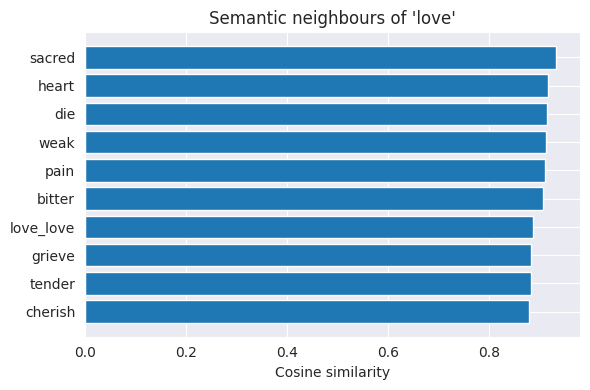

In [76]:
"""
Bar chart of the 10 words most similar to a query word, ordered by cosine
similarity.  This is the Word2Vec neighbourhood visualisation from the
Gensim tutorial, re-anchored on a COHA drama keyword.
"""

import matplotlib.pyplot as plt

query_word = "love"
words_sim, sims = zip(*w2v_model.wv.most_similar(query_word, topn=10))

plt.figure(figsize=(6, 4))
plt.barh(words_sim, sims)
plt.gca().invert_yaxis()
plt.xlabel("Cosine similarity")
plt.title(f"Semantic neighbours of '{query_word}'")
plt.tight_layout()
plt.show()

2D projection (PCA)

In [86]:
# Raw list — useful for inspecting the actual scores
w2v_model.wv.most_similar(query_word)

"""### 2D projection (PCA)

Project the word vectors of a hand-picked list down to two dimensions with PCA,
then plot them.  Words with similar usage contexts cluster together.
"""

from sklearn.decomposition import PCA
import numpy as np

In [78]:
# Select words that are meaningful in the COHA drama domain
# and are guaranteed to be in the vocabulary (adjust if needed)
pca_words = [w for w in
             ["love", "honour", "sword", "death",
              "villain", "hero", "father", "daughter"]
             if w in w2v_model.wv.key_to_index]

vectors = np.array([w2v_model.wv[w] for w in pca_words])


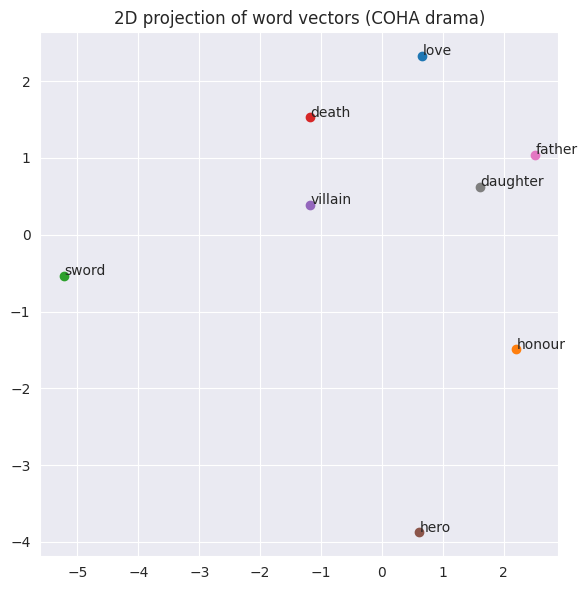

In [79]:
pca    = PCA(n_components=2)
coords = pca.fit_transform(vectors)

plt.figure(figsize=(6, 6))
for i, word in enumerate(pca_words):
    plt.scatter(coords[i, 0], coords[i, 1])
    plt.text(coords[i, 0] + 0.01, coords[i, 1] + 0.01, word)

plt.title("2D projection of word vectors (COHA drama)")
plt.tight_layout()
plt.show()

### Odd-one-out

In [80]:
#Define a function to find the "odd one out"
def odd_one_out(words):
    #keep only words that exist in the model vocabulary
    in_vocab = [w for w in words if w in w2v_model.wv]

    #ensure there are enough valid words for comparison
    if len(in_vocab) < 3:
        print(f"Need at least 3 in-vocab words; found: {in_vocab}")
        return

    #find the word least similar to the others
    result = w2v_model.wv.doesnt_match(in_vocab)
    print(f"Odd one out from {in_vocab}: '{result}'")

#Example 1:
# "sword" is expected to differ from emotion-related words
odd_one_out([
    "love",
    "passion",
    "heart",
    "sword"
])

#Example 2:
# "enemy" is expected to differ from family-related words
odd_one_out([
    "father",
    "mother",
    "daughter",
    "enemy"
])

Odd one out from ['love', 'passion', 'heart', 'sword']: 'sword'
Odd one out from ['father', 'mother', 'daughter', 'enemy']: 'enemy'


### Analogy — vector arithmetic

Classic Word2Vec analogy: *king − man + woman ≈ queen*

In the COHA drama context we can try:
- *daughter − father + mother ≈ ?*
- *honour − man + woman ≈ ?*

In [81]:
# Define a helper function for word analogies
def analogy(positive, negative, topn=3):
    """
    positive : list
        Words that contribute positively to the analogy.

    negative : list
        Words that are subtracted from the analogy.

    topn : int
        Number of most similar results to return.
    """

    try:
        #compute the most similar words using vector arithmetic
        results = w2v_model.wv.most_similar(
            positive=positive,
            negative=negative,
            topn=topn
        )

        #create a readable equation string
        eq = " + ".join(positive) + " - " + " - ".join(negative)

        #display the analogy expression
        print(f"\n{eq}  →")

        #print each result with its similarity score
        for w, score in results:
            print(f"  {w:<20} {score:.4f}")

    #handle missing words in the vocabulary
    except KeyError as e:
        print(f"KeyError: {e}")


# Example 1:
# daughter + mother - father
# Tests family relationship embeddings
analogy(
    positive=["daughter", "mother"],
    negative=["father"]
)

# Example 2:
# honour + woman - man
# Explores gender associations in embeddings
analogy(
    positive=["honour", "woman"],
    negative=["man"]
)


daughter + mother - father  →
  embrace              0.8825
  parent               0.8778
  mourn                0.8753

honour + woman - man  →
  true                 0.8248
  heir                 0.7854
  proof                0.7848


## 7. t-SNE Visualizations

We reduce the `vector_size`-dimensional embeddings to 2D using PCA + t-SNE and plot:
- The **query word** in red
- Its **10 most similar** words in blue
- A **comparison list** in green

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#tools for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#display plots directly inside the notebook
%matplotlib inline

#set Seaborn plot style
sns.set_style("darkgrid")


def tsnescatterplot(model, word, list_names, title=None):
    """
    Create a t-SNE visualization for:
    - the target word (shown in red)
    - its top 10 most similar words (shown in blue)
    - additional comparison words from `list_names` (shown in green)
    """

    #get the embedding vector size from the Word2Vec model
    dim = model.wv.vector_size

    #initialize arrays and metadata containers
    arrays = np.empty((0, dim), dtype='f')
    word_labels = [word]
    color_list = ['red']

    #add the vector for the target/query word
    arrays = np.append(arrays, model.wv[word].reshape(1, -1), axis=0)

    #retrieve and add the top 10 most similar words
    for wrd, _ in model.wv.most_similar([word], topn=10):

        #append the word vector
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)

        #store label and display color
        word_labels.append(wrd)
        color_list.append('blue')

    #add comparison words from the provided list
    #ignore words that are not in the vocabulary (OOV = Out Of Vocabulary)
    for wrd in list_names:
        if wrd in model.wv:

            #append the word vector
            arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)

            #store label and display color
            word_labels.append(wrd)
            color_list.append('green')

    # Dimensionality reduction

    # First reduce dimensions using PCA
    # Limit PCA dimensions to:
    # 50 maximum
    # number of samples - 1
    # original embedding dimension
    n_pca = min(50, arrays.shape[0] - 1, dim)

    reduc = PCA(n_components=n_pca).fit_transform(arrays)

    #set perplexity for t-SNE
    #must be smaller than the number of samples
    perp = min(15, reduc.shape[0] - 1)

    #reduce to 2D using t-SNE
    Y = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perp
    ).fit_transform(reduc)

    #create a DataFrame for plotting
    df_plot = pd.DataFrame({
        'x': Y[:, 0],
        'y': Y[:, 1],
        'words': word_labels,
        'color': color_list
    })

    # Plotting

    #create figure and axes
    fig, ax = plt.subplots(figsize=(10, 10))

    #draw scatter plot
    sns.scatterplot(
        data=df_plot,
        x='x',
        y='y',
        hue='color',
        palette={
            'red': 'red',
            'blue': 'royalblue',
            'green': 'seagreen'
        },
        s=60,
        legend=False,
        ax=ax
    )

    #add text labels next to each point
    for _, row in df_plot.iterrows():
        ax.text(
            row['x'] + 0.5,
            row['y'],
            row['words'].title(),
            fontsize=11,
            color=row['color'],
            weight='normal'
        )

    #set plot title
    ax.set_title(title or f't-SNE — "{word}"', fontsize=14)

    #improve spacing
    plt.tight_layout()

    #display the plot
    plt.show()


#confirmation message
print("tsnescatterplot() defined.")

tsnescatterplot() defined.


### Plot 1 — `love` vs. random semantic neighbours

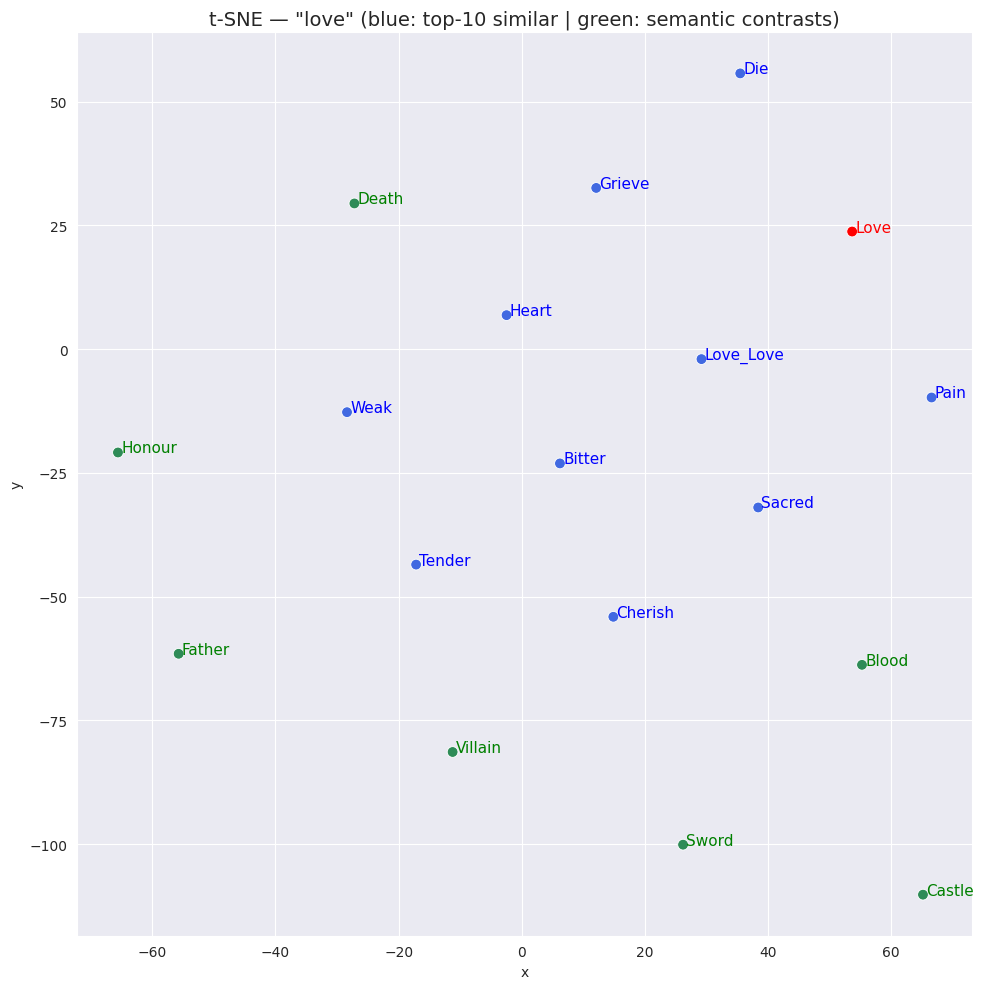

In [83]:
tsnescatterplot(
    w2v_model,
    word       = 'love',
    list_names = ['sword', 'death', 'villain', 'blood', 'castle', 'father', 'honour'],
    title      = 't-SNE — "love" (blue: top-10 similar | green: semantic contrasts)'
)

### Plot 2 — `fate` vs. its 10 most dissimilar words

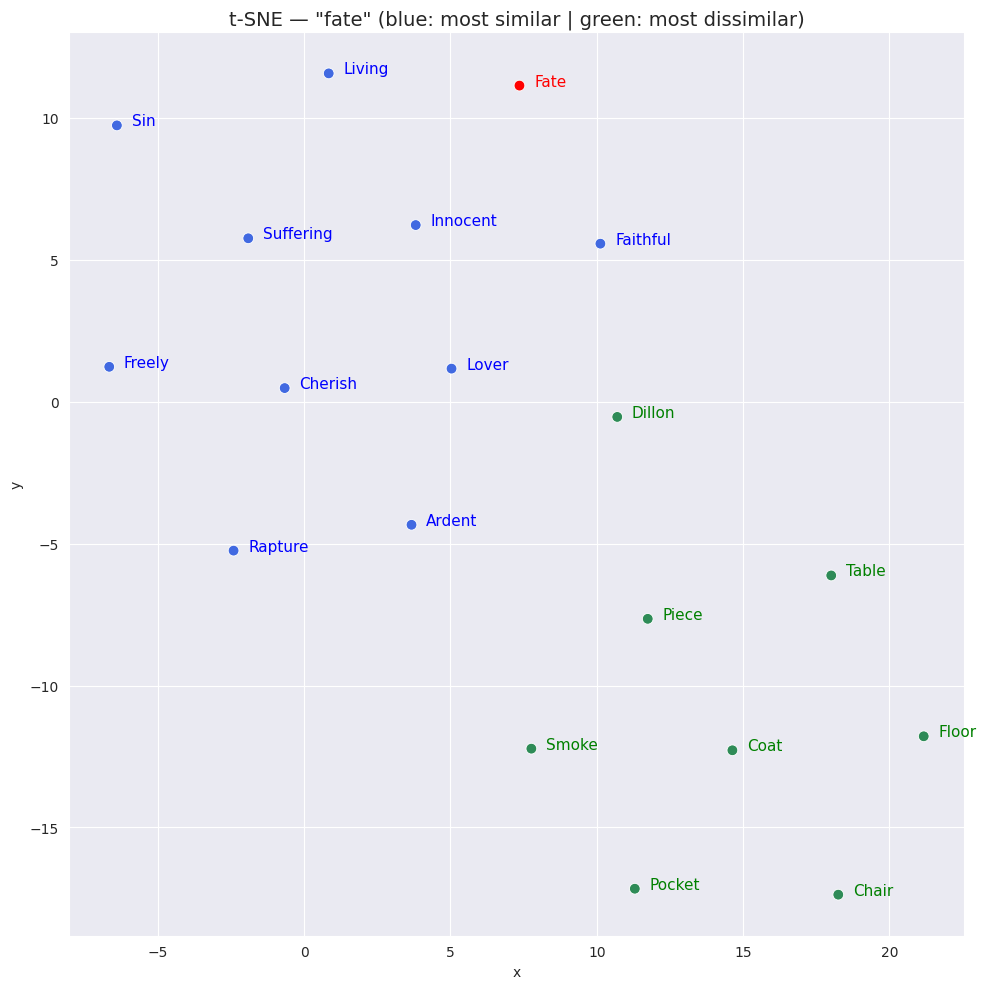

In [84]:
tsnescatterplot(
    w2v_model,
    word       = 'fate',
    list_names = [w for w, _ in w2v_model.wv.most_similar(negative=['fate'], topn=8)],
    title      = 't-SNE — "fate" (blue: most similar | green: most dissimilar)'
)

### Plot 3 — `honour`: top 1–10 vs. top 11–20 similar words

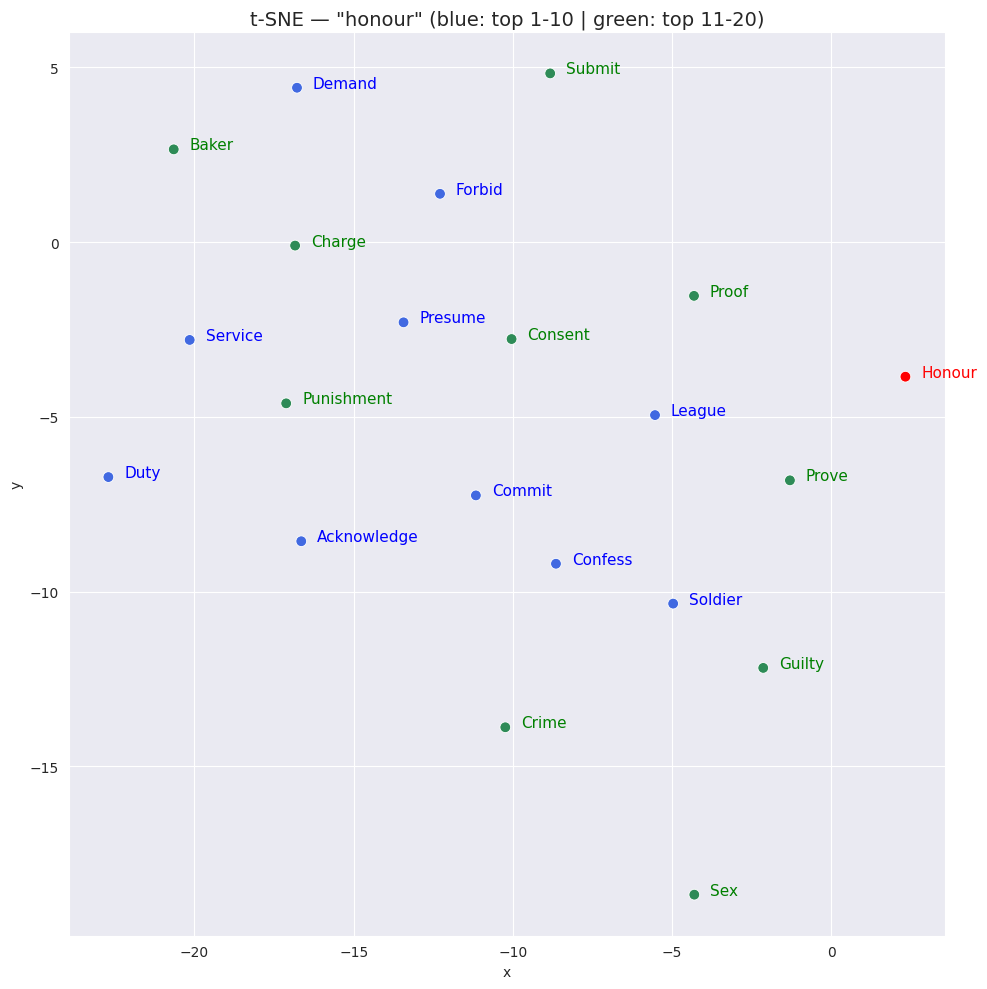

In [85]:
#try using the British spelling "honour"
try:
    # Get the 20 most similar words to "honour"
    top20 = [w for w, _ in w2v_model.wv.most_similar(positive=['honour'], topn=20)]

    # Visualize the word and its similar words with t-SNE
    tsnescatterplot(
        w2v_model,
        word='honour',
        list_names=top20[10:],  # Display words ranked 11–20
        title='t-SNE — "honour" (blue: top 1-10 | green: top 11-20)'
    )

# If "honour" is not found in the vocabulary,
# fall back to the American spelling "honor"
except KeyError:

    # Get the 20 most similar words to "honor"
    top20 = [w for w, _ in w2v_model.wv.most_similar(positive=['honor'], topn=20)]

    # Visualize the results for "honor"
    tsnescatterplot(
        w2v_model,
        'honor',
        top20[10:]
    )